# Figure 2g – Local radial profiles at three atom positions

Reads `data/processed/figure_2g.csv` and saves `figures/figure_2g.png`.


In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style, pretty_plot_radial_profile

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=2.0)


In [4]:
df   = pd.read_csv(PROCESSED / 'figure_2g.csv')
freq = df['freq'].values

rp_C67   = df['rp_C67'].values
rp_B443  = df['rp_B443'].values
rp_E332  = df['rp_E332'].values

fsc_C67  = df['fsc_res_C67'].iloc[0]
fsc_B443 = df['fsc_res_B443'].iloc[0]
fsc_E332 = df['fsc_res_E332'].iloc[0]


Saved figures/figure_2g.png


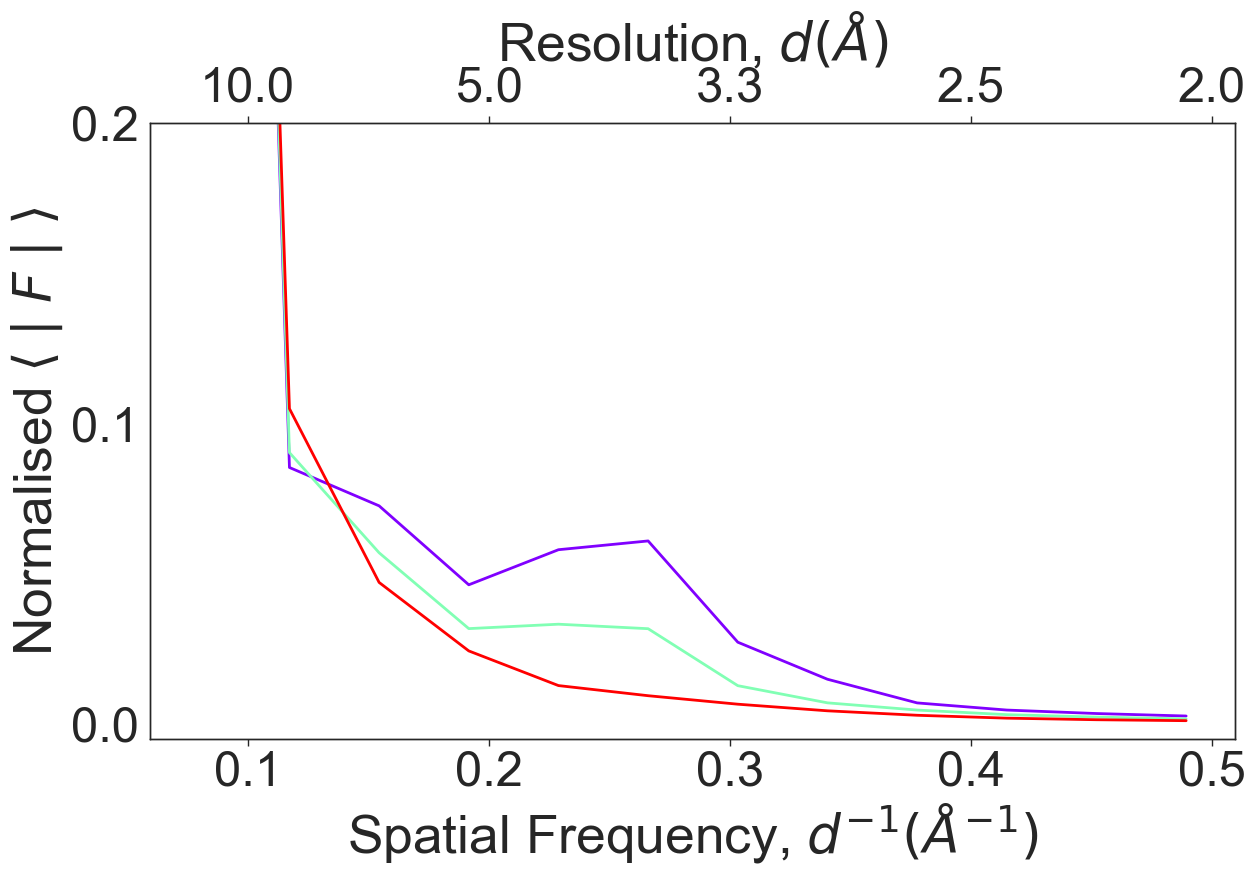

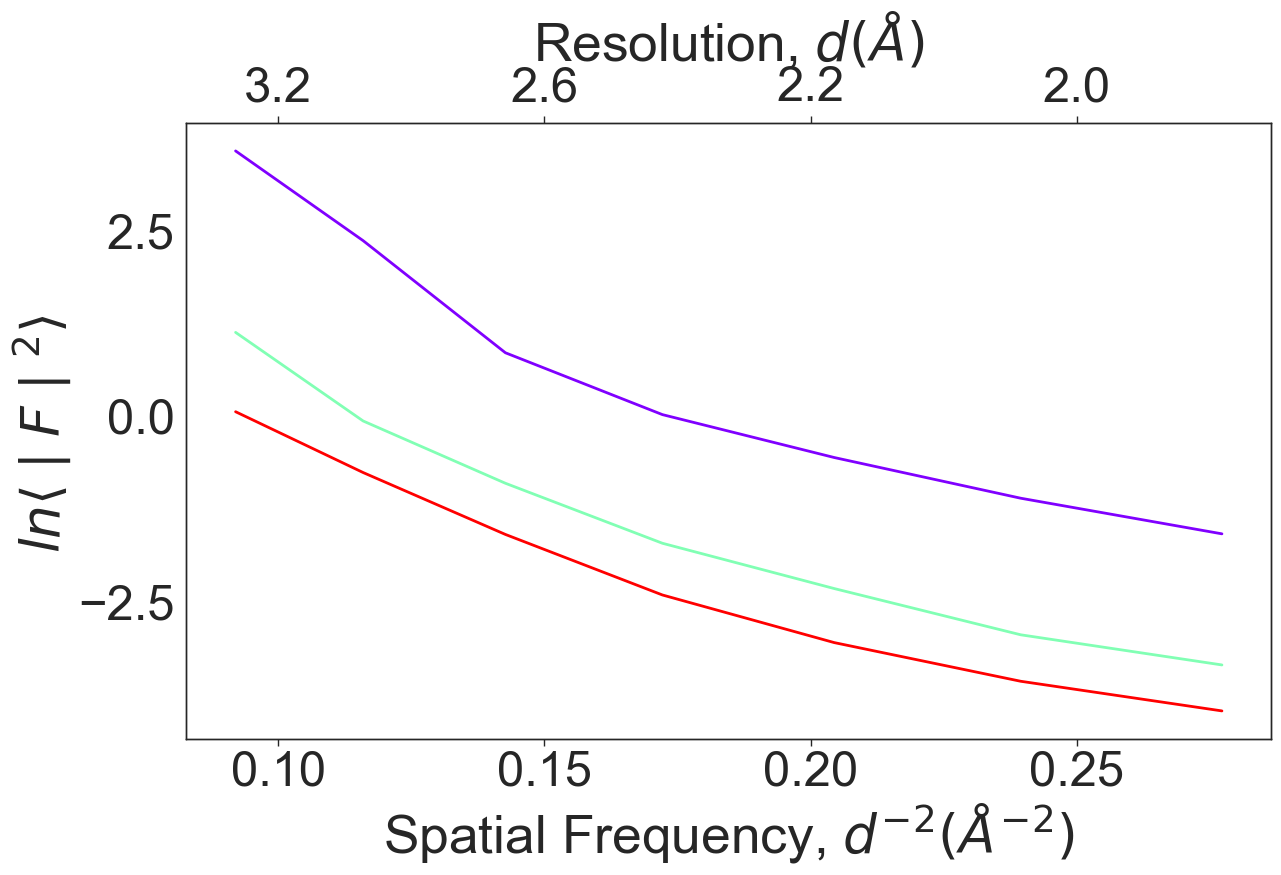

In [13]:
labels = [
    f'FSC-FDR: {fsc_C67:.1f}',
    f'FSC-FDR: {fsc_B443:.1f}',
    f'FSC-FDR: {fsc_E332:.1f}',
]

fig1 = pretty_plot_radial_profile(
        freq, 
        [rp_C67, rp_B443, rp_E332], 
        showlegend=False, 
        normalise=True, 
        logScale=False, 
        ylims=[-0.005,0.2],
        yticks=[0,0.1,0.2],
        crop_freq=[100,2], 
        linewidth=2, 
        fontscale=4
    )

fig2 = pretty_plot_radial_profile(
        freq, 
        [rp_C67, rp_B443, rp_E332], 
        showlegend=False, 
        squared_amplitudes=True,
        normalise=False, 
        logScale=True, 
        #ylims=[-0.005,0.2],
        yticks=[-2.5,0,2.5],
        crop_freq=[3.5,1.8], 
        linewidth=2, 
        fontscale=4
    )

# fig = plot_radial_profiles(
#     freq, [rp_C67, rp_B443, rp_E332],
#     labels=labels,
#     log_scale=False,
#     normalized=False,
#     squared=False,
#     crop_freq=None,
#     ylims=[-0.005, 0.2],
#     linewidth=2,
#     figsize=(7, 5),
#     fontsize=12,
# )
fig1.savefig(FIGURES / 'figure_2g.png', dpi=300, bbox_inches='tight', format='png')
print('Saved figures/figure_2g.png')
